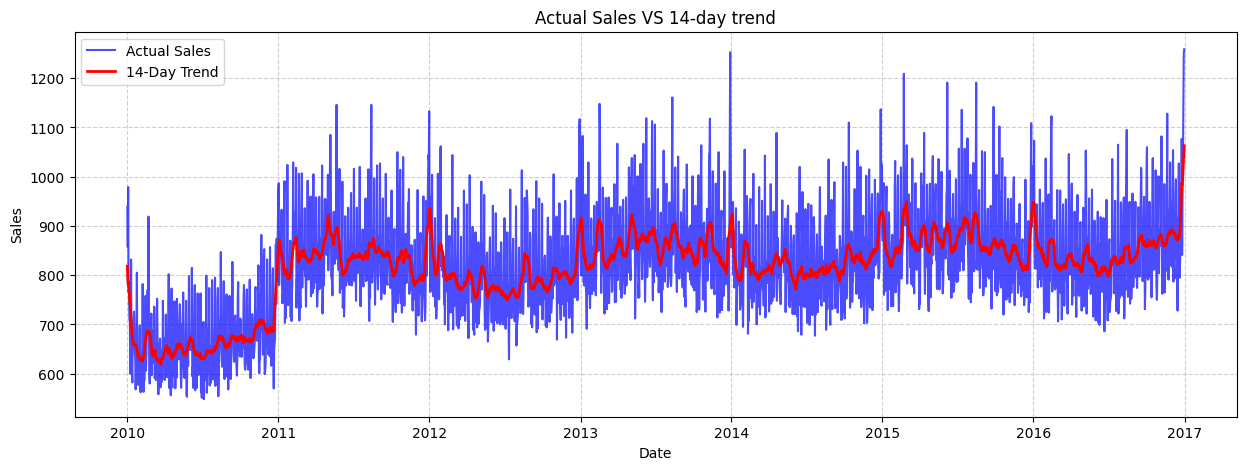

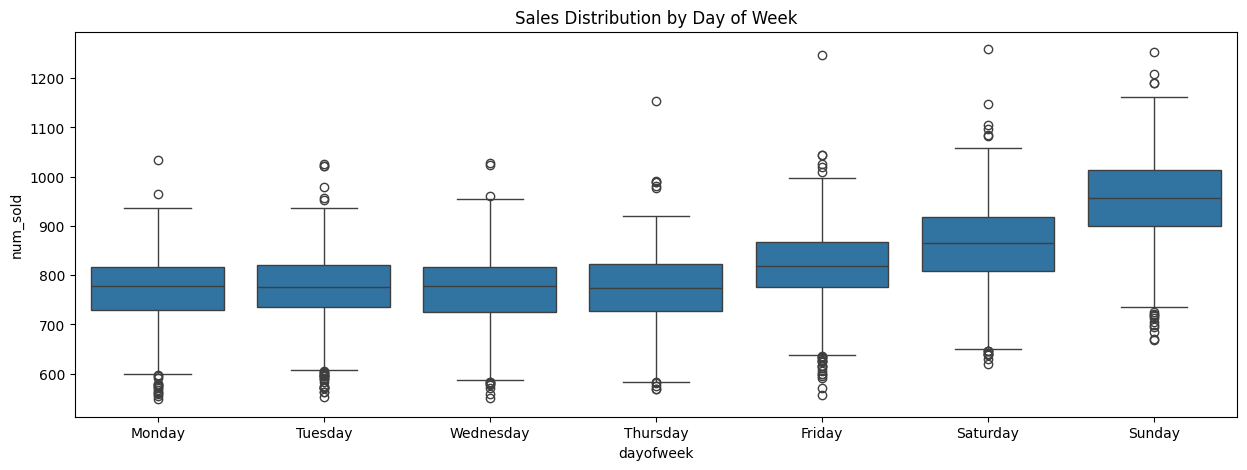

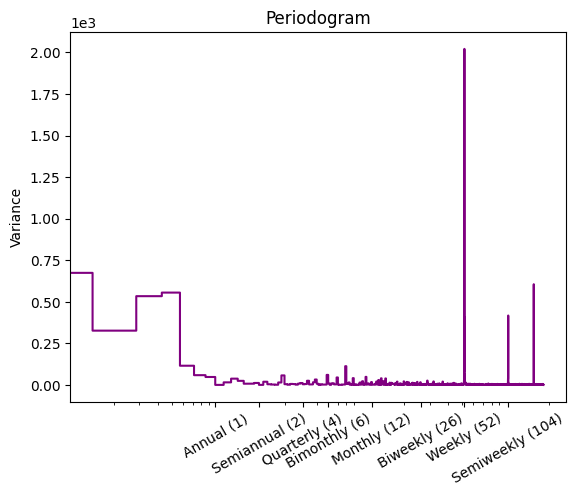

0.06439321386335453


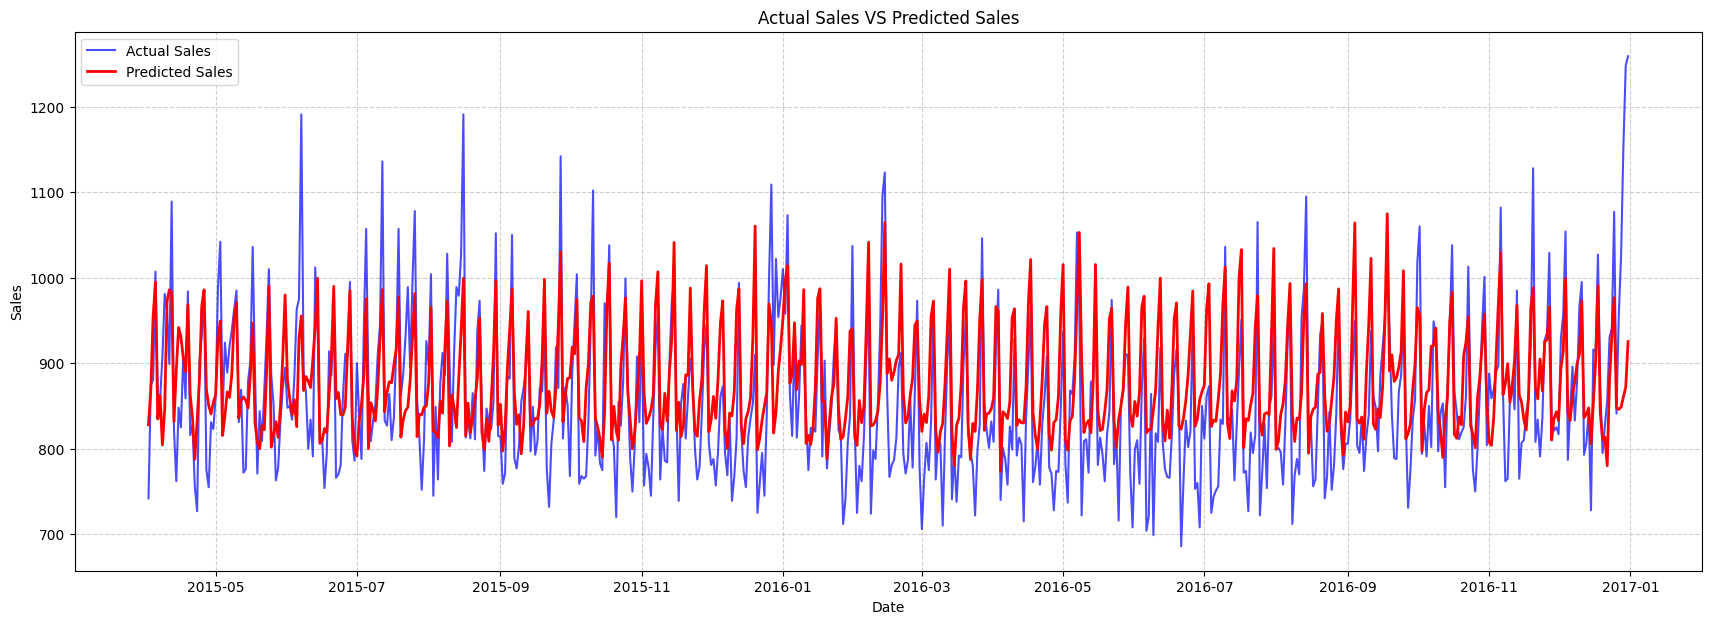

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.deterministic import DeterministicProcess

from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from sklearn.metrics import  mean_absolute_percentage_error


df = pd.read_csv('../data/train.csv')
df['date'] = pd.to_datetime(df['date'])
df['dayofweek'] = df['date'].dt.day_name()
sale = df['num_sold']
df = df.sort_values(by=['date', 'country', 'store', 'product']).reset_index(drop=True)

le = LabelEncoder()
df['dayofweek_encoded'] = le.fit_transform(df['dayofweek'])

df['month'] = df['date'].dt.month
df['day_of_year'] = df['date'].dt.dayofyear
df['is_weekend'] = df['dayofweek'].isin(['Saturday', 'Sunday']).astype(int)
df_base = df[(df['product'] == 'Kaggle') & (df['store'] == 'Discount Stickers') & (df['country'] == 'Singapore')].copy()
df_base['dayofweek'] = df_base['date'].dt.day_name()

sale = df_base['num_sold']
moving_avg = sale.rolling(window = 14, min_periods = 7, center = True).mean()

plt.figure(figsize=(15, 5))
plt.plot(df_base['date'], sale, color = 'blue', alpha = 0.7, label='Actual Sales')
plt.plot(df_base['date'], moving_avg, color = 'red', linewidth = 2, label='14-Day Trend')
plt.title('Actual Sales VS 14-day trend')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True , linestyle='--', alpha=0.6)
plt.savefig('../data/plot/Actual VS Trend(Baseline).png', dpi=300, bbox_inches='tight')

plt.figure(figsize=(15, 5))
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.boxplot(x = df_base['dayofweek'], y = sale, order = order)
plt.title('Sales Distribution by Day of Week')
plt.savefig('../data/plot/Weekly_Seasonality.png', dpi=300, bbox_inches='tight')
plt.show()

def plot_periodogram(ts, detrend='linear', ax=None):
    from scipy.signal import periodogram
    fs = pd.Timedelta("365D") / pd.Timedelta("1D")
    freqencies, spectrum = periodogram(
        ts,
        fs=fs,
        detrend=detrend,
        window="boxcar",
        scaling='spectrum',
    )
    if ax is None:
        _, ax = plt.subplots()
    ax.step(freqencies, spectrum, color="purple")
    ax.set_xscale("log")
    ax.set_xticks([1, 2, 4, 6, 12, 26, 52, 104])
    ax.set_xticklabels(
        [
            "Annual (1)",
            "Semiannual (2)",
            "Quarterly (4)",
            "Bimonthly (6)",
            "Monthly (12)",
            "Biweekly (26)",
            "Weekly (52)",
            "Semiweekly (104)",
        ],
        rotation=30,
    )
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.set_ylabel("Variance")
    ax.set_title("Periodogram")
    return ax

plot_periodogram(sale)
plt.savefig('../data/plot/Periodogram.png', dpi=300, bbox_inches='tight')
plt.show()

df_base['date'] = pd.to_datetime(df_base['date']).copy()
df_base.set_index('date', inplace=True)
df_base.index = df_base.index.to_period('D')
sale = df_base['num_sold']
dp_index = df_base.index
dp = DeterministicProcess(index = dp_index, constant = True, order = 1, drop = True, seasonal = True, period = 7)
X_time = dp.in_sample()

def make_mean_lags(ts):
    return pd.concat({'mean_lag_7': ts.rolling(window = 7).mean().shift(1),
                      'mean_lag_30': ts.rolling(window = 30).mean().shift(1),
                      'mean_lag_last_week': ts.rolling(window = 7).mean().shift(7)}, axis = 1)


X = pd.concat([X_time, make_mean_lags(sale)], axis = 1)
sale, X = sale.align(X, join = 'inner')

X_train, X_val, y_train, y_val = train_test_split(X, sale, test_size=0.25, shuffle = False)
prototype = XGBRegressor(n_estimators = 200, learning_rate = 0.1, random_state = 0)
prototype.fit(X_train, y_train)
predicted_sale = prototype.predict(X_val)
MAPE = mean_absolute_percentage_error(y_val, predicted_sale)
print(MAPE)


plt.figure(figsize=(21, 7))
plt.plot(y_val.index.to_timestamp(), y_val, color = 'blue', alpha = 0.7, label='Actual Sales')
plt.plot(y_val.index.to_timestamp(), predicted_sale, color = 'red', linewidth = 2, label='Predicted Sales')
plt.title('Actual Sales VS Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True , linestyle='--', alpha=0.6)
plt.savefig('../data/plot/Actual Sales VS Predicted Sales(Baseline).png', dpi=300, bbox_inches='tight')
plt.show()